## Module 5: Analyse, diagnose and improve a model​

In the excercise of this week you will be working with financial data in order to (hopefully) find a portfolio of equities which outperform SP500. The data that you are gonna work with has two main sources: 
* Financial data from the companies extracted from the quarterly company reports (mostly extracted from [macrotrends](https://www.macrotrends.net/) so you can use this website to understand better the data and get insights on the features, for example [this](https://www.macrotrends.net/stocks/charts/AAPL/apple/revenue) is the one corresponding to APPLE)
* Stock prices, mostly extracted from [morningstar](https://indexes.morningstar.com/page/morningstar-indexes-empowering-investor-success?utm_source=google&utm_medium=cpc&utm_campaign=MORNI%3AG%3ASearch%3ABrand%3ACore%3AUK%20MORNI%3ABrand%3ACore%3ABroad&utm_content=engine%3Agoogle%7Ccampaignid%3A18471962329%7Cadid%3A625249340069&utm_term=morningstar%20index&gclid=CjwKCAjws9ipBhB1EiwAccEi1Fu6i20XHVcxFxuSEtJGF0If-kq5-uKnZ3rov3eRkXXFfI5j8QBtBBoCayEQAvD_BwE), which basically tell us how the stock price is evolving so we can use it both as past features and the target to predict).

Before going to the problem that we want to solve, let's comment some of the columns of the dataset:


* `Ticker`: a [short name](https://en.wikipedia.org/wiki/Ticker_symbol) to identify the equity (that you can use to search in macrotrends)
* `date`: the date of the company report (normally we are gonna have 1 every quarter). This is for informative purposes but you can ignore it when modeling.
* `execution date`: the date when we would had executed the algorithm for that equity. We want to execute the algorithm once per quarter to create the portfolio, but the release `date`s of all the different company reports don't always match for the quarter, so we just take a common `execution_date` for all of them.
* `stock_change_div_365`: what is the % change of the stock price (with dividens) in the FOLLOWING year after `execution date`. 
* `sp500_change_365`: what is the % change of the SP500 in the FOLLOWING year after `execution date`.
* `close_0`: what is the price at the moment of `execution date`
* `stock_change__minus_120` what is the % change of the stock price in the last 120 days
* `stock_change__minus_730`: what is the % change of the stock price in the last 730 days

The rest of the features can be divided beteween financial features (the ones coming from the reports) and technical features (coming from the stock price). We leave the technical features here as a reference: 

In [101]:
technical_features = ['close_0', 'close_sp500_0', 'close_365', 'close_sp500_365',
       'close__minus_120', 'close_sp500__minus_120', 'close__minus_365',
       'close_sp500__minus_365', 'close__minus_730', 'close_sp500__minus_730',
       'stock_change_365','stock_change_div_365', 'sp500_change_365', 'stock_change__minus_120',
       'sp500_change__minus_120', 'stock_change__minus_365',
       'sp500_change__minus_365', 'stock_change__minus_730','sp500_change__minus_730',
       'std__minus_365','std__minus_730','std__minus_120']

The problem that we want to solve is basically find a portfolio of `top_n` tickers (initially set to 10) to invest every `execution date` (basically once per quarter) and the goal is to have a better return than `SP500` in the following year. The initial way to model this is to have a binary target which is 1 when `stock_change_div_365` - `sp500_change_365` (the difference between the return of the equity and the SP500 in the following year) is positive or 0 otherwise. So we try to predict the probability of an equity of improving SP500 in the following year, we take the `top_n` equities and compute their final return.

In [102]:
import pandas as pd
import re
import numpy as np
import lightgbm as lgb
from plotnine import ggplot, geom_histogram, aes, geom_col, coord_flip,geom_bar,scale_x_discrete, geom_point, theme,element_text, theme_minimal

In [103]:
# number of trees in lightgbm
n_trees = 40
minimum_number_of_tickers = 1500
# Number of the quarters in the past to train
n_train_quarters = 36
# number of tickers to make the portfolio
top_n = 10

In [104]:
import os
os.chdir('/home/miguel/zrive-ds')
data_set = pd.read_feather("data/finances/financials_against_return.feather")

Remove these quarters which have les than `minimum_number_of_tickers` tickers:

In [105]:
df_quarter_lengths = data_set.groupby(["execution_date"]).size().reset_index().rename(columns = {0:"count"})
data_set = pd.merge(data_set, df_quarter_lengths, on = ["execution_date"])
data_set = data_set[data_set["count"]>=minimum_number_of_tickers]

In [106]:
data_set.shape

(170483, 145)

Create the target:

In [107]:
data_set["diff_ch_sp500"] = data_set["stock_change_div_365"] - data_set["sp500_change_365"]

data_set.loc[data_set["diff_ch_sp500"]>0,"target"] = 1
data_set.loc[data_set["diff_ch_sp500"]<0,"target"] = 0

data_set["target"].value_counts()

target
0.0    82437
1.0    73829
Name: count, dtype: int64

This function computes the main metric that we want to optimize: given a prediction where we have probabilities for each equity, we sort the equities in descending order of probability, we pick the `top_n` ones, and we we weight the returned `diff_ch_sp500` by the probability:

In [108]:
def get_weighted_performance_of_stocks(df,metric):
    df["norm_prob"] = 1/len(df)
    return np.sum(df["norm_prob"]*df[metric])

def get_top_tickers_per_prob(preds):
    if len(preds) == len(train_set):
        data_set = train_set.copy()
    elif len(preds) == len(test_set):
        data_set = test_set.copy()
    else:
        assert ("Not matching train/test")
    data_set["prob"] = preds
    data_set = data_set.sort_values(["prob"], ascending = False)
    data_set = data_set.head(top_n)
    return data_set

# main metric to evaluate: average diff_ch_sp500 of the top_n stocks
def top_wt_performance(preds, train_data):
    top_dataset = get_top_tickers_per_prob(preds)
    return "weighted-return", get_weighted_performance_of_stocks(top_dataset,"diff_ch_sp500"), True

We have created for you a function to make the `train` and `test` split based on a `execution_date`:

In [109]:
def split_train_test_by_period(data_set, test_execution_date,include_nulls_in_test = False):
    # we train with everything happening at least one year before the test execution date
    train_set = data_set.loc[data_set["execution_date"] <= pd.to_datetime(test_execution_date) - pd.Timedelta(350, unit = "day")]
    # remove those rows where the target is null
    train_set = train_set[~pd.isna(train_set["diff_ch_sp500"])]
    execution_dates = train_set.sort_values("execution_date")["execution_date"].unique()
    # Pick only the last n_train_quarters
    if n_train_quarters!=None:
        train_set = train_set[train_set["execution_date"].isin(execution_dates[-n_train_quarters:])]
        
    # the test set are the rows happening in the execution date with the concrete frequency
    test_set = data_set.loc[(data_set["execution_date"] == test_execution_date)]
    if not include_nulls_in_test:
        test_set = test_set[~pd.isna(test_set["diff_ch_sp500"])]
    test_set = test_set.sort_values('date', ascending = False).drop_duplicates('Ticker', keep = 'first')
    
    return train_set, test_set

Ensure that we don't include features which are irrelevant or related to the target:

In [110]:
def get_columns_to_remove():
    columns_to_remove = [
                         "date",
                         "improve_sp500",
                         "Ticker",
                         "freq",
                         "set",
                         "close_sp500_365",
                         "close_365",
                         "stock_change_365",
                         "sp500_change_365",
                         "stock_change_div_365",
                         "stock_change_730",
                         "sp500_change_365",
                         "stock_change_div_730",
                         "diff_ch_sp500",
                         "diff_ch_avg_500",
                         "execution_date","target","index","quarter","std_730","count"]
        
    return columns_to_remove

This is the main modeling function, it receives a train test and a test set and trains a `lightgbm` in classification mode. We don't recommend to change the main algorithm for this excercise but we suggest to play with its hyperparameters:

In [111]:
import warnings
warnings.filterwarnings('ignore')


def train_model(train_set,test_set,n_estimators = 300):

    columns_to_remove = get_columns_to_remove()
    
    X_train = train_set.drop(columns = columns_to_remove, errors = "ignore")
    X_test = test_set.drop(columns = columns_to_remove, errors = "ignore")
    
    
    y_train = train_set["target"]
    y_test = test_set["target"]

    lgb_train = lgb.Dataset(X_train,y_train)
    lgb_test = lgb.Dataset(X_test, y_test, reference=lgb_train)
    
    eval_result = {}
    
 
    objective = 'binary'
    metric = 'binary_logloss' 
    params = {
             "random_state":1, 
             "verbosity": -1,
             "n_jobs":10, 
             "n_estimators":n_estimators,
             "objective": objective,
             "metric": metric}
    
    model = lgb.train(params = params,
                      train_set = lgb_train,
                      valid_sets = [lgb_train, lgb_test],
                      valid_names=["Train", "Test"],
                      feval = [top_wt_performance],
                      callbacks = [lgb.record_evaluation(eval_result = eval_result)])
    return model,eval_result,X_train,X_test


 
            

This is the function which receives an `execution_date` and splits the dataset between train and test, trains the models and evaluates the model in test. It returns a dictionary with the different evaluation metrics in train and test:

In [112]:
def run_model_for_execution_date(execution_date,all_results,all_predicted_tickers_list,all_models,n_estimators,include_nulls_in_test = False):
        global train_set
        global test_set
        # split the dataset between train and test
        train_set, test_set = split_train_test_by_period(data_set,execution_date,include_nulls_in_test = include_nulls_in_test)
        train_size, _ = train_set.shape
        test_size, _ = test_set.shape
        model = None
        X_train = None
        X_test = None
        
        # if both train and test are not empty
        if train_size > 0 and test_size>0:
            model, evals_result, X_train, X_test = train_model(train_set,
                                                              test_set,
                                                              n_estimators = n_estimators)
            
            test_set['prob'] = model.predict(X_test)
            predicted_tickers = test_set.sort_values('prob', ascending = False)
            predicted_tickers["execution_date"] = execution_date
            all_results[(execution_date)] = evals_result
            all_models[(execution_date)] = model
            all_predicted_tickers_list.append(predicted_tickers)
        return all_results,all_predicted_tickers_list,all_models,model,X_train,X_test


execution_dates = np.sort( data_set['execution_date'].unique() )


This is the main training loop: it goes through each different `execution_date` and calls `run_model_for_execution_date`. All the results are stored in `all_results` and the predictions in `all_predicted_tickers_list`.

In [113]:
all_results = {}
all_predicted_tickers_list = []
all_models = {}

for execution_date in execution_dates:
    print(execution_date)
    all_results,all_predicted_tickers_list,all_models,model,X_train,X_test = run_model_for_execution_date(execution_date,all_results,all_predicted_tickers_list,all_models,n_trees,False)
all_predicted_tickers = pd.concat(all_predicted_tickers_list) 

2005-06-30T00:00:00.000000000
2005-09-30T00:00:00.000000000
2005-12-30T00:00:00.000000000
2006-03-31T00:00:00.000000000
2006-06-30T00:00:00.000000000
2006-09-30T00:00:00.000000000
2006-12-30T00:00:00.000000000
2007-03-31T00:00:00.000000000
2007-06-30T00:00:00.000000000
2007-09-30T00:00:00.000000000
2007-12-30T00:00:00.000000000
2008-03-31T00:00:00.000000000
2008-06-30T00:00:00.000000000
2008-09-30T00:00:00.000000000
2008-12-30T00:00:00.000000000
2009-03-31T00:00:00.000000000
2009-06-30T00:00:00.000000000
2009-09-30T00:00:00.000000000
2009-12-30T00:00:00.000000000
2010-03-31T00:00:00.000000000
2010-06-30T00:00:00.000000000
2010-09-30T00:00:00.000000000
2010-12-30T00:00:00.000000000
2011-03-31T00:00:00.000000000
2011-06-30T00:00:00.000000000
2011-09-30T00:00:00.000000000
2011-12-30T00:00:00.000000000
2012-03-31T00:00:00.000000000
2012-06-30T00:00:00.000000000
2012-09-30T00:00:00.000000000
2012-12-30T00:00:00.000000000
2013-03-31T00:00:00.000000000
2013-06-30T00:00:00.000000000
2013-09-30

In [114]:
def parse_results_into_df(set_):
    df = pd.DataFrame()
    for date in all_results:
        df_tmp = pd.DataFrame(all_results[(date)][set_])
        df_tmp["n_trees"] = list(range(len(df_tmp)))
        df_tmp["execution_date"] = date
        df= pd.concat([df,df_tmp])
    
    df["execution_date"] = df["execution_date"].astype(str)
    
    return df

In [115]:
test_results = parse_results_into_df("Test")
train_results = parse_results_into_df("Train")

In [116]:
test_results_final_tree = test_results.sort_values(["execution_date","n_trees"]).drop_duplicates("execution_date",keep = "last")
train_results_final_tree = train_results.sort_values(["execution_date","n_trees"]).drop_duplicates("execution_date",keep = "last")


And this are the results:

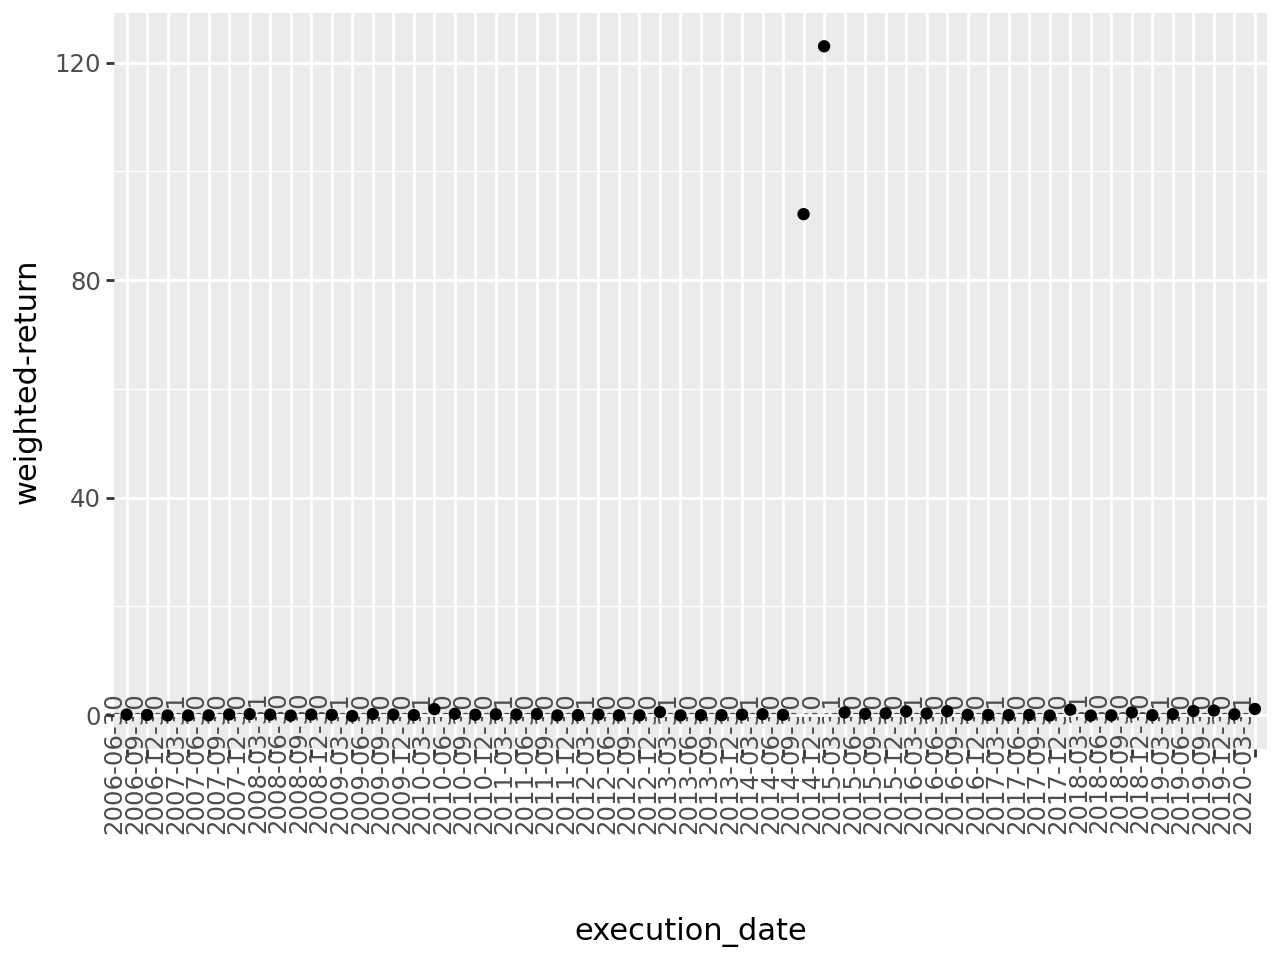

In [117]:
ggplot(test_results_final_tree) + geom_point(aes(x = "execution_date", y = "weighted-return")) + theme(axis_text_x = element_text(angle = 90, vjust = 0.5, hjust=1))

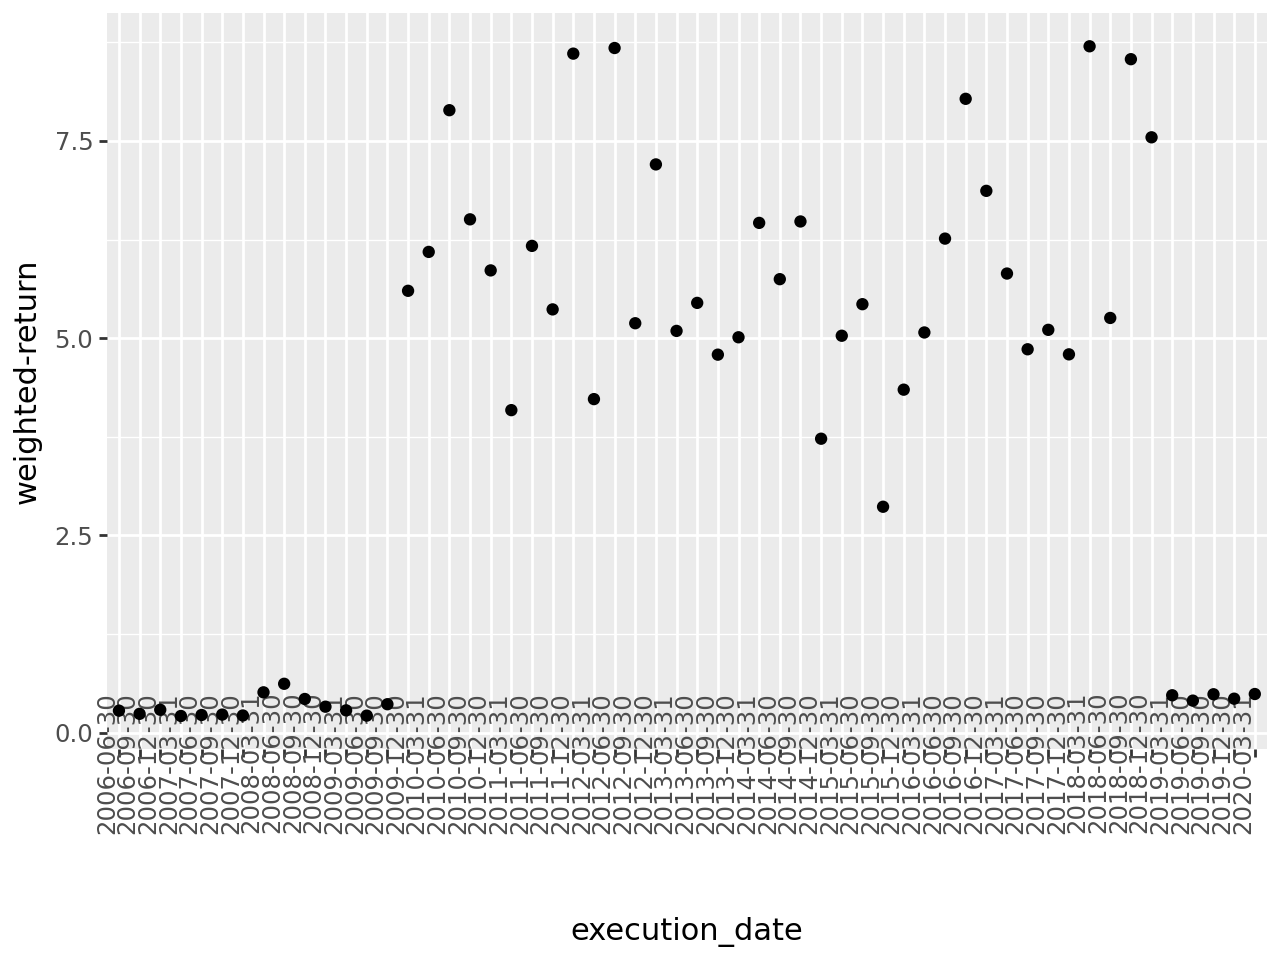

In [118]:
ggplot(train_results_final_tree) + geom_point(aes(x = "execution_date", y = "weighted-return")) + theme(axis_text_x = element_text(angle = 90, vjust = 0.5, hjust=1))


We have trained the first models for all the periods for you, but there are a lot of things which may be wrong or can be improved. Some ideas where you can start:
* Try to see if there is any kind of data leakage or suspicious features
* If the training part is very slow, try to see how you can modify it to execute faster tests
* Try to understand if the algorithm is learning correctly
* We are using a very high level metric to evaluate the algorithm so you maybe need to use some more low level ones
* Try to see if there is overfitting
* Try to see if there is a lot of noise between different trainings
* To simplify, why if you only keep the first tickers in terms of Market Cap?
* Change the number of quarters to train in the past

This function can be useful to compute the feature importance:

In [119]:
def draw_feature_importance(model,top = 15): # NO USAR, NO ES LA MEJOR
    fi = model.feature_importance()
    fn = model.feature_name()
    feature_importance = pd.DataFrame([{"feature":fn[i],"imp":fi[i]} for i in range(len(fi))])
    feature_importance = feature_importance.sort_values("imp",ascending = False).head(top)
    feature_importance = feature_importance.sort_values("imp",ascending = True)
    plot = ggplot(feature_importance,aes(x = "feature",y  = "imp")) + geom_col(fill = "lightblue") + coord_flip() +  scale_x_discrete(limits = feature_importance["feature"])
    return plot


In [120]:
from scipy.stats import lognorm
import matplotlib.pyplot as plt

---

# Proposed modifications:

In [121]:
train_outperformance = train_results_final_tree[train_results_final_tree['weighted-return'] > 0].shape[0] / train_results_final_tree.shape[0]
test_outperformance = test_results_final_tree[test_results_final_tree['weighted-return'] > 0].shape[0] / test_results_final_tree.shape[0]
print(f'Percentage of execution dates in which the chosen portfolio outperforms SP500 in train dataset: {round(train_outperformance*100, 2)}')
print(f'Percentage of execution dates in which the chosen portfolio outperforms SP500 in test dataset: {round(test_outperformance*100, 2)}')
print('\n')
mean_train_performance_difference = train_results_final_tree['weighted-return'].mean()
mean_test_performance_difference = test_results_final_tree['weighted-return'].mean()
print(f'Mean difference in performance (between our portfolio and SP500) for train dataset: {round(mean_train_performance_difference, 4)}')
print(f'Mean difference in performance (between our portfolio and SP500) for test dataset: {round(mean_test_performance_difference, 4)}')
print('\n')
median_train_performance_difference = train_results_final_tree['weighted-return'].median()
median_test_performance_difference = test_results_final_tree['weighted-return'].median()
print(f'Median difference in performance (between our portfolio and SP500) for train dataset: {round(median_train_performance_difference, 4)}')
print(f'Median difference in performance (between our portfolio and SP500) for test dataset: {round(median_test_performance_difference, 4)}')

Percentage of execution dates in which the chosen portfolio outperforms SP500 in train dataset: 100.0
Percentage of execution dates in which the chosen portfolio outperforms SP500 in test dataset: 71.43


Mean difference in performance (between our portfolio and SP500) for train dataset: 4.0254
Mean difference in performance (between our portfolio and SP500) for test dataset: 4.029


Median difference in performance (between our portfolio and SP500) for train dataset: 5.0203
Median difference in performance (between our portfolio and SP500) for test dataset: 0.1047


Firstly, as it can be seen in the plotted graphs, there is a significant difference between performance in train and test: for train data, we obtain a 100% outperformance rate over SP-500, whilst in test data it reduces to a 71.43%. Even more concerning: the median difference in performance in train is around 5, while only 0.1 is observed in test. The mean values are much closer since in test, we encounter some big outliers which favour the results for our model. These big differences between train and test performance suggests a problem of either overfitting, information leakage, or even both at the same time. Let's check feature importance:

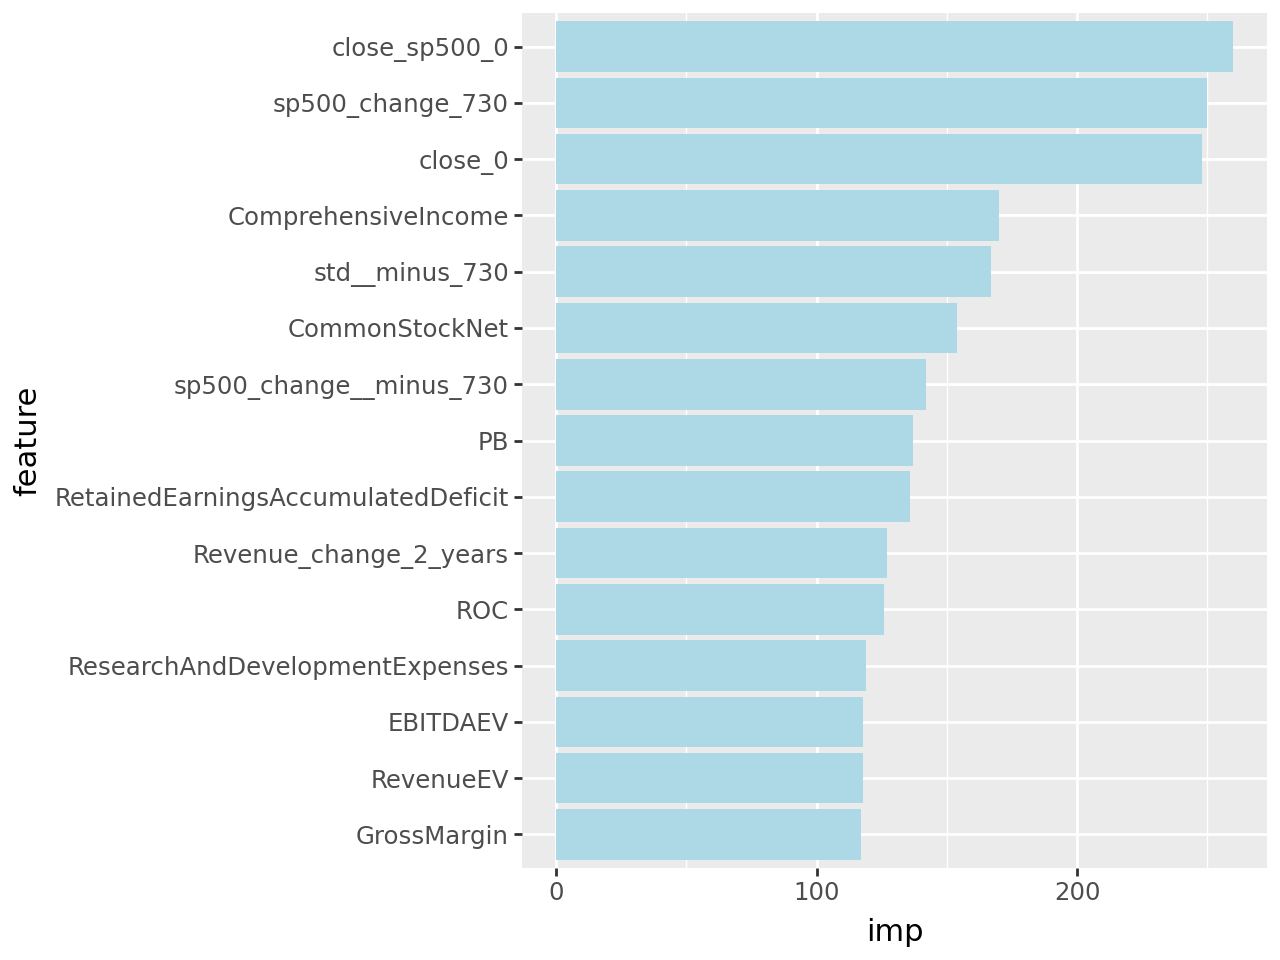

In [122]:
last_execution_date = '2021-03-27T00:00:00.000000000'

train_set, test_set = split_train_test_by_period(data_set,last_execution_date,include_nulls_in_test = True)
model, eval_result, X_train, X_test = train_model(train_set,test_set,n_estimators = 300)
draw_feature_importance(model,top = 15)

In [123]:
# Quick check (dates where the data is split)
random_execution_date = data_set["execution_date"].iloc[int(len(data_set["execution_date"])/2+36652)]; print(random_execution_date, '\n')
train_set, test_set = split_train_test_by_period(data_set,random_execution_date,include_nulls_in_test = False)

print(train_set["execution_date"].iloc[0])
print(train_set["execution_date"].iloc[-1])
print('\n')
print(test_set["execution_date"].iloc[0])
print(test_set["execution_date"].iloc[-1])

2017-09-30 00:00:00 

2007-12-30 00:00:00
2016-09-30 00:00:00


2017-09-30 00:00:00
2017-09-30 00:00:00


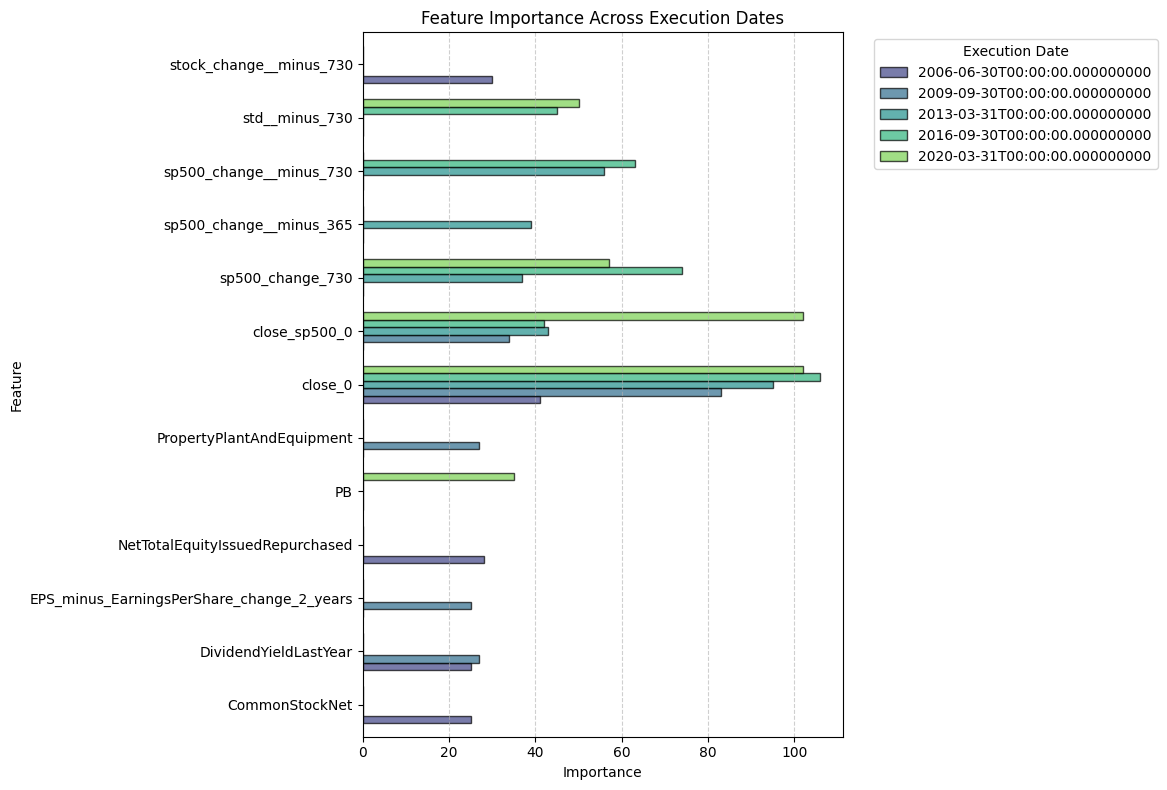

In [124]:
num_models = 5
sorted_dates = sorted(all_models.keys())
selected_indexes = np.linspace(0, len(sorted_dates) - 1, num_models, dtype=int)
selected_dates = [sorted_dates[i] for i in selected_indexes]
selected_models = [all_models[date] for date in selected_dates]

all_feature_importance = []

for date, model in zip(selected_dates, selected_models):
    fi = model.feature_importance()
    fn = model.feature_name()
    
    feature_importance = pd.DataFrame({
        "feature": fn,
        "importance": fi,
        "execution_date": str(date) 
    })

    feature_importance = feature_importance.sort_values("importance", ascending=False).head(5)
    
    all_feature_importance.append(feature_importance)

df_feature_importance = pd.concat(all_feature_importance)

pivot_df = df_feature_importance.pivot(index="feature", columns="execution_date", values="importance")

fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(pivot_df.columns)))

pivot_df.plot(kind="barh", ax=ax, alpha=0.7, color=colors, edgecolor="black", width=0.7)

ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.set_title("Feature Importance Across Execution Dates")
ax.legend(title="Execution Date", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

##### **Feature importance utilizando Shap**

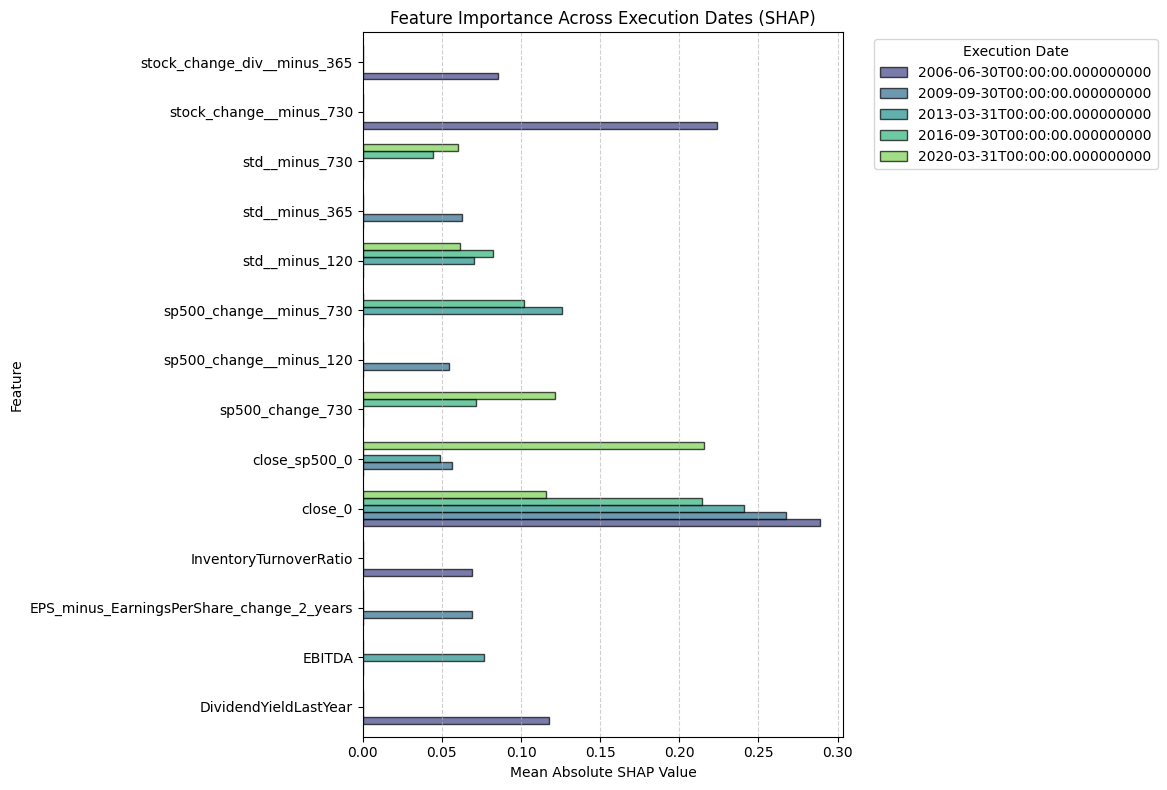

In [125]:
import shap

num_models = 5
sorted_dates = sorted(all_models.keys())
selected_indexes = np.linspace(0, len(sorted_dates) - 1, num_models, dtype=int)
selected_dates = [sorted_dates[i] for i in selected_indexes]
selected_models = [all_models[date] for date in selected_dates]

all_feature_importance = []

for date, model in zip(selected_dates, selected_models):
    feature_names = model.feature_name()
    
    # Compute SHAP values
    explainer = shap.TreeExplainer(model)
    X_sample = X_train.sample(n=500, random_state=42)  # Subsample for efficiency
    shap_values = explainer.shap_values(X_sample)

    # For binary classification, use shap_values[1] (positive class contributions)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  

    # Compute mean absolute SHAP value per feature
    mean_shap_values = np.abs(shap_values).mean(axis=0)
    
    feature_importance = pd.DataFrame({
        "feature": feature_names,
        "importance": mean_shap_values,
        "execution_date": str(date) 
    })

    feature_importance = feature_importance.sort_values("importance", ascending=False).head(5)
    
    all_feature_importance.append(feature_importance)

df_feature_importance = pd.concat(all_feature_importance)

pivot_df = df_feature_importance.pivot(index="feature", columns="execution_date", values="importance")

fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(pivot_df.columns)))

pivot_df.plot(kind="barh", ax=ax, alpha=0.7, color=colors, edgecolor="black", width=0.7)

ax.set_xlabel("Mean Absolute SHAP Value")
ax.set_ylabel("Feature")
ax.set_title("Feature Importance Across Execution Dates (SHAP)")
ax.legend(title="Execution Date", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

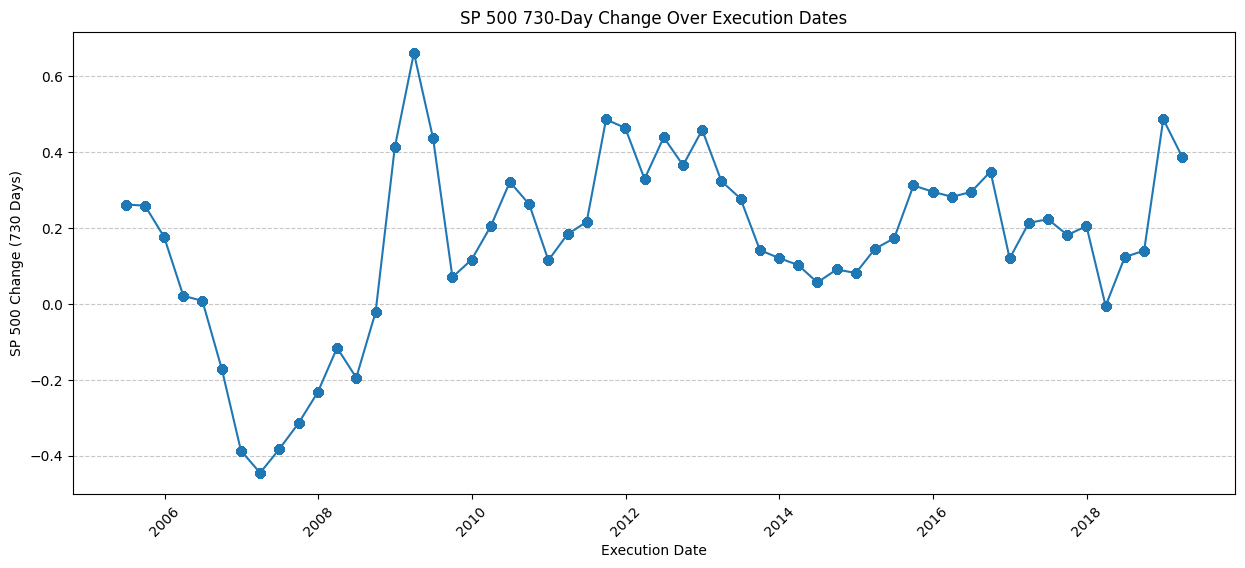

In [126]:
plt.figure(figsize=(15, 6))
plt.plot(data_set['execution_date'], data_set['sp500_change_730'], marker='o', linestyle='-')

plt.xlabel("Execution Date")
plt.ylabel("SP 500 Change (730 Days)")
plt.title("SP 500 730-Day Change Over Execution Dates")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

As it was expected, the suspicious variable `sp500_change_730` seems to be information "from the future", holding data of the % change of the stock price (with dividens) 2 years after `execution date`. The first suspicious fact is the existence of another feature `sp500_change__minus_730`, which is clearly from 2 years before. After that, I checked for NaN values in `sp500_change_730` and, as we expected, it has NaNs for every `execution date` after 2019-03-30 (exactly 2 years before the end of the dataset). This confirms that we are committing information leakage (at least) through this feature.

With a further investigation, we notice that both `close_0` and `close_sp500_0` features are data being published/obtained at the exact same moment when we are computing our top_n tickers. This means that we will not have this information when deploying the model in production.

In [127]:
train_columns_list = train_set.columns.tolist()
print("\n".join(train_columns_list))

Ticker
date
AssetTurnover
CashFlowFromFinancialActivities
CashFlowFromInvestingActivities
CashFlowFromOperatingActivities
CashOnHand
ChangeInAccountsPayable
ChangeInAccountsReceivable
ChangeInAssetsLiabilities
ChangeInInventories
CommonStockDividendsPaid
CommonStockNet
ComprehensiveIncome
CostOfGoodsSold
CurrentRatio
DaysSalesInReceivables
DebtIssuanceRetirementNet_minus_Total
DebtEquityRatio
EBIT
EBITMargin
EBITDA
EBITDAMargin
FinancialActivities_minus_Other
GoodwillAndIntangibleAssets
GrossMargin
GrossProfit
IncomeAfterTaxes
IncomeFromContinuousOperations
IncomeFromDiscontinuedOperations
IncomeTaxes
Inventory
InventoryTurnoverRatio
InvestingActivities_minus_Other
LongTermDebt
Long_minus_TermInvestments
Long_minus_termDebtCapital
NetAcquisitionsDivestitures
NetCashFlow
NetChangeInIntangibleAssets
NetChangeInInvestments_minus_Total
NetChangeInLong_minus_TermInvestments
NetChangeInPropertyPlantAndEquipment
NetChangeInShort_minus_termInvestments
NetCommonEquityIssuedRepurchased
NetCurren

**Columns added to the function `columns_to_remove`:**

 `sp500_change_730`, `close_0` and `close_sp500_0`.

### **Possible overfitting?**
Let's dive into plotting the phase and learning curves in order to visualize the progress of training.

In [128]:
def plot_phase_curve(evals_result):
    plt.figure(figsize=(10, 5))

    train_loss = evals_result["Train"]["binary_logloss"]
    test_loss = evals_result["Test"]["binary_logloss"]
    
    plt.plot(train_loss, label="Train Loss", marker=".", linestyle="-")
    plt.plot(test_loss, label="Test Loss", marker=".", linestyle="-")

    plt.xlabel("Boosting Rounds (Iterations)")
    plt.ylabel("Binary Logloss")
    plt.title("LightGBM Phase Curve (Loss vs Iterations)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

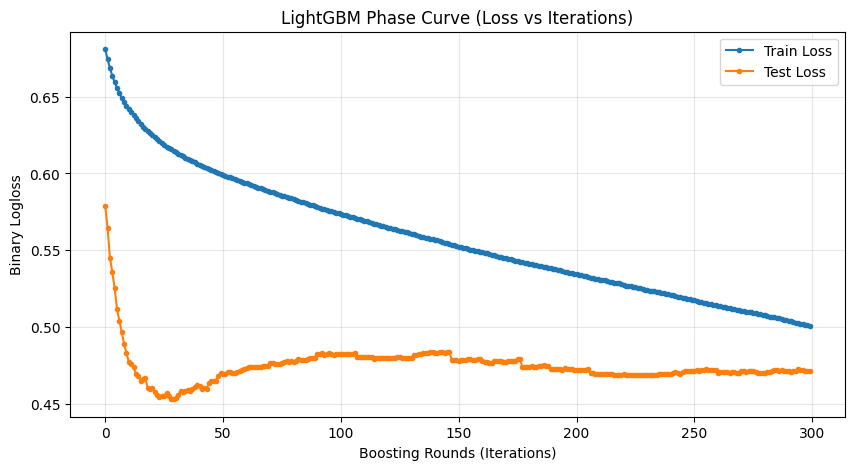

In [129]:
plot_phase_curve(evals_result=eval_result)

In [130]:
from plotnine import geom_boxplot, labs

def plot_phase_curve_boxplot(evals_results_dict):
    """
    Visualizes the learning curves as a series of boxplots, showing 
    the distribution of logloss values at different execution dates.

    Parameters:
    - evals_results_dict: Dictionary with execution dates as keys and evals_result as values.
                          Each evals_result contains 'Train' and 'Test' logloss metrics.

    Returns:
    - ggplot boxplot of logloss distributions across execution dates.
    """
    
    df_list = []
    
    for execution_date, evals_result in evals_results_dict.items():
        train_loss = evals_result["Train"]["binary_logloss"]
        test_loss = evals_result["Test"]["binary_logloss"]
        
        df_temp = pd.DataFrame({
            "Boosting Round": list(range(len(train_loss))) * 2,
            "Logloss": train_loss + test_loss,
            "Dataset": ["Train"] * len(train_loss) + ["Test"] * len(test_loss),
            "Execution Date": str(execution_date)
        })
        
        df_list.append(df_temp)

    df_logloss = pd.concat(df_list, ignore_index=True)

    plot = (
        ggplot(df_logloss, aes(x="Execution Date", y="Logloss", fill="Dataset")) +
        geom_boxplot(alpha=0.6) +
        labs(title="Learning Curve Evolution (Logloss Distribution)",
             x="Execution Date", y="Binary Logloss") +
        theme_minimal()
    )

    return plot

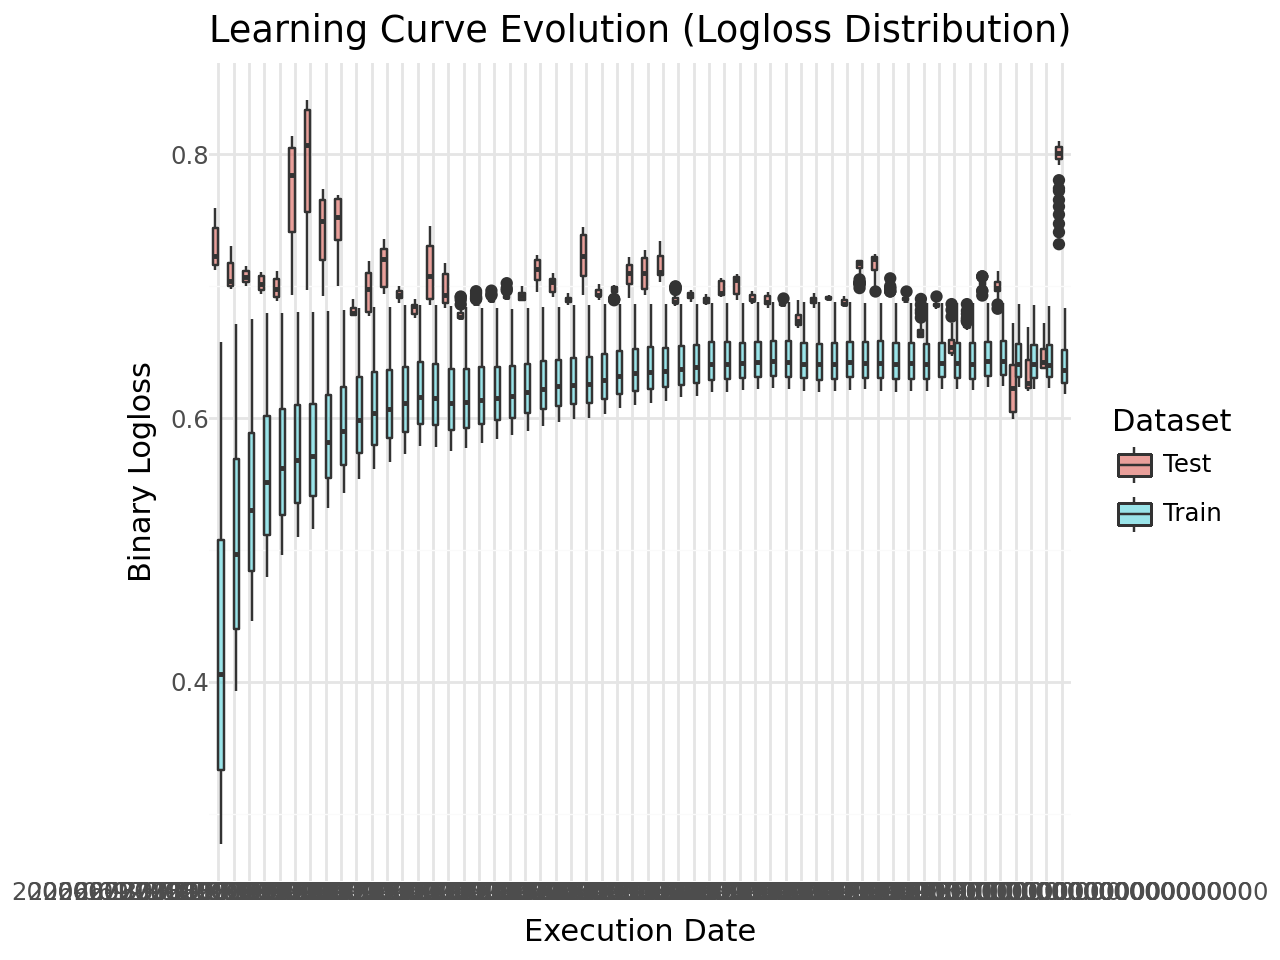

In [131]:
ggplot_phase_curve = plot_phase_curve_boxplot(all_results)
ggplot_phase_curve

In [132]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, log_loss

def tune_lgbm_hyperparameters(train_set, test_set, param_grid=None, cv_folds=3):
    """
    Performs hyperparameter tuning using GridSearchCV for LightGBM.
    
    Parameters:
    - train_set: Training dataset (DataFrame)
    - test_set: Testing dataset (DataFrame)
    - param_grid: Dictionary of hyperparameters to tune
    - cv_folds: Number of cross-validation folds (default=5)
    
    Returns:
    - Best LightGBM model trained with optimal hyperparameters
    - Best hyperparameters found
    """

    columns_to_remove = get_columns_to_remove()
    X_train = train_set.drop(columns=columns_to_remove, errors="ignore")
    y_train = train_set["target"]

    if param_grid is None:
        param_grid = {
            'learning_rate': [0.01, 0.1],
            'num_leaves': [31, 50],
            'max_depth': [-1, 5],
            # 'min_child_samples': [10, 20],
            # 'reg_alpha': [0, 0.1, 0.5],  # L1 regularization
            # 'reg_lambda': [0, 0.1, 0.5],  # L2 regularization
            'n_estimators': [100, 300]
        }

    # Define the model
    lgb_model = lgb.LGBMClassifier(random_state=1, verbosity=-1, n_jobs=10)

    # Define scoring metric (log loss)
    scorer = make_scorer(log_loss, greater_is_better=False, needs_proba=True)

    grid_search = GridSearchCV(
        estimator=lgb_model,
        param_grid=param_grid,
        scoring=scorer,
        cv=cv_folds,
        verbose=2,
        n_jobs=10  
    )

    grid_search.fit(X_train, y_train)

    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_

    print("\nBest Hyperparameters Found:", best_params)
    return best_model, best_params

In [133]:
# best_model, best_params = tune_lgbm_hyperparameters(train_set, test_set)

## **Redefine functions (where necessary)**

In [134]:
def get_columns_to_remove2():
    columns_to_remove = [
                         "date",
                         "improve_sp500",
                         "Ticker",
                         "freq",
                         "set",
                         "close_sp500_365",
                         "close_365",
                         "stock_change_365",
                         "sp500_change_365",
                         "stock_change_div_365",
                         "stock_change_730",
                         "sp500_change_365",
                         "stock_change_div_730",
                         "diff_ch_sp500",
                         "diff_ch_avg_500",
                         "execution_date",
                         "target",
                         "index",
                         "quarter",
                         "std_730",
                         "count",
                         "sp500_change_730",
                         "close_0",
                         "close_sp500_0"
                         ]
        
    return columns_to_remove

def train_model2(train_set,test_set,n_estimators = 20):

    columns_to_remove = get_columns_to_remove2()
    
    X_train = train_set.drop(columns = columns_to_remove, errors = "ignore")
    X_test = test_set.drop(columns = columns_to_remove, errors = "ignore")
    
    
    y_train = train_set["target"]
    y_test = test_set["target"]

    lgb_train = lgb.Dataset(X_train,y_train)
    lgb_test = lgb.Dataset(X_test, y_test, reference=lgb_train)
    
    eval_result = {}
    
 
    objective = 'binary'
    metric = 'binary_logloss' 
    params = {
             "random_state":1, 
             "verbosity": -1,
             "n_jobs":10, 
             "n_estimators":n_estimators,
             "objective": objective,
             "metric": metric}
    
    model = lgb.train(params = params,
                      train_set = lgb_train,
                      valid_sets = [lgb_train, lgb_test],
                      valid_names=["Train", "Test"],
                      feval = [top_wt_performance],
                      callbacks = [lgb.record_evaluation(eval_result = eval_result)])
    return model,eval_result,X_train,X_test

def run_model_for_execution_date2(execution_date,all_results,all_predicted_tickers_list,all_models,n_estimators,include_nulls_in_test = False):
        global train_set
        global test_set
        # split the dataset between train and test
        train_set, test_set = split_train_test_by_period(data_set,execution_date,include_nulls_in_test = include_nulls_in_test)
        train_size, _ = train_set.shape
        test_size, _ = test_set.shape
        model = None
        X_train = None
        X_test = None
        
        # if both train and test are not empty
        if train_size > 0 and test_size>0:
            model, evals_result, X_train, X_test = train_model2(train_set,
                                                              test_set,
                                                              n_estimators = n_estimators)
            
            test_set['prob'] = model.predict(X_test)
            predicted_tickers = test_set.sort_values('prob', ascending = False)
            predicted_tickers["execution_date"] = execution_date
            all_results[(execution_date)] = evals_result
            all_models[(execution_date)] = model
            all_predicted_tickers_list.append(predicted_tickers)
        return all_results,all_predicted_tickers_list,all_models,model,X_train,X_test


execution_dates = np.sort( data_set['execution_date'].unique() )

In [135]:
all_results = {}
all_predicted_tickers_list = []
all_models = {}

for execution_date in execution_dates:
    print(execution_date)
    all_results,all_predicted_tickers_list,all_models,model,X_train,X_test = run_model_for_execution_date2(execution_date,all_results,all_predicted_tickers_list,all_models,n_trees,False)
all_predicted_tickers = pd.concat(all_predicted_tickers_list) 

test_results = parse_results_into_df("Test")
train_results = parse_results_into_df("Train")

test_results_final_tree = test_results.sort_values(["execution_date","n_trees"]).drop_duplicates("execution_date",keep = "last")
train_results_final_tree = train_results.sort_values(["execution_date","n_trees"]).drop_duplicates("execution_date",keep = "last")

2005-06-30T00:00:00.000000000
2005-09-30T00:00:00.000000000
2005-12-30T00:00:00.000000000
2006-03-31T00:00:00.000000000
2006-06-30T00:00:00.000000000
2006-09-30T00:00:00.000000000
2006-12-30T00:00:00.000000000
2007-03-31T00:00:00.000000000
2007-06-30T00:00:00.000000000
2007-09-30T00:00:00.000000000
2007-12-30T00:00:00.000000000
2008-03-31T00:00:00.000000000
2008-06-30T00:00:00.000000000
2008-09-30T00:00:00.000000000
2008-12-30T00:00:00.000000000
2009-03-31T00:00:00.000000000
2009-06-30T00:00:00.000000000
2009-09-30T00:00:00.000000000
2009-12-30T00:00:00.000000000
2010-03-31T00:00:00.000000000
2010-06-30T00:00:00.000000000
2010-09-30T00:00:00.000000000
2010-12-30T00:00:00.000000000
2011-03-31T00:00:00.000000000
2011-06-30T00:00:00.000000000
2011-09-30T00:00:00.000000000
2011-12-30T00:00:00.000000000
2012-03-31T00:00:00.000000000
2012-06-30T00:00:00.000000000
2012-09-30T00:00:00.000000000
2012-12-30T00:00:00.000000000
2013-03-31T00:00:00.000000000
2013-06-30T00:00:00.000000000
2013-09-30

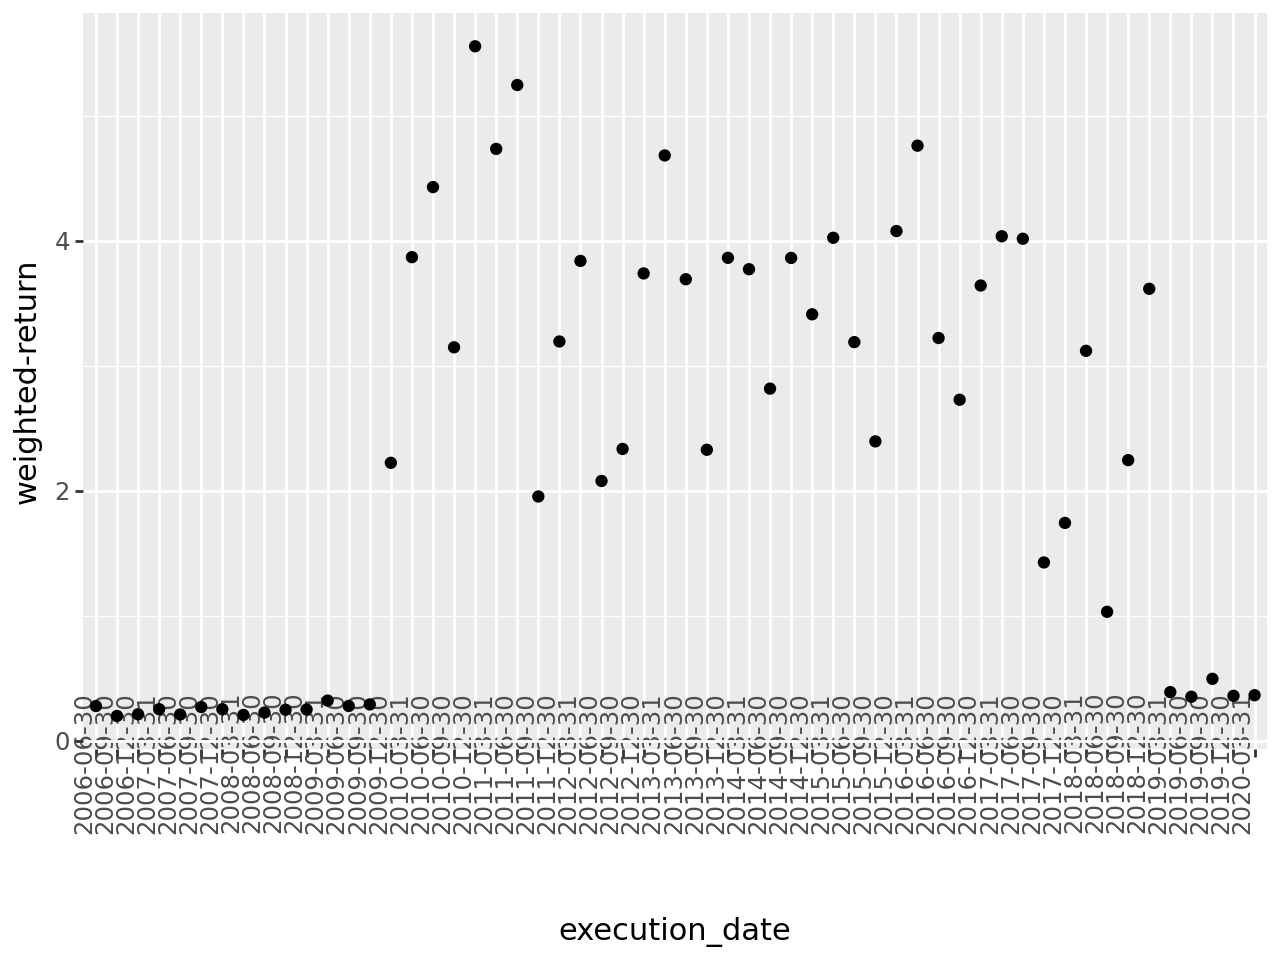

In [136]:
ggplot(train_results_final_tree) + geom_point(aes(x = "execution_date", y = "weighted-return")) + theme(axis_text_x = element_text(angle = 90, vjust = 0.5, hjust=1))

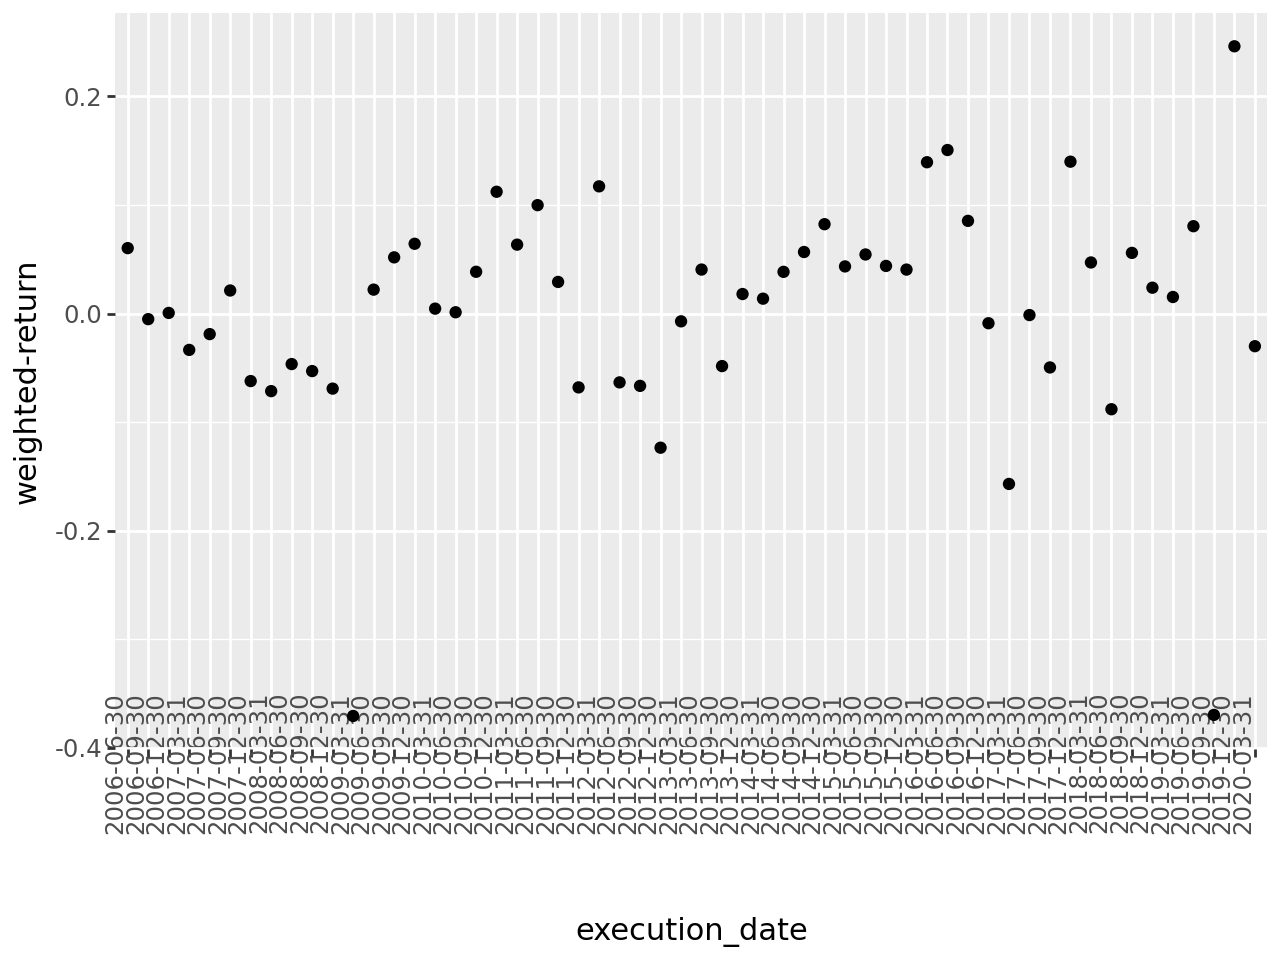

In [137]:
ggplot(test_results_final_tree) + geom_point(aes(x = "execution_date", y = "weighted-return")) + theme(axis_text_x = element_text(angle = 90, vjust = 0.5, hjust=1))

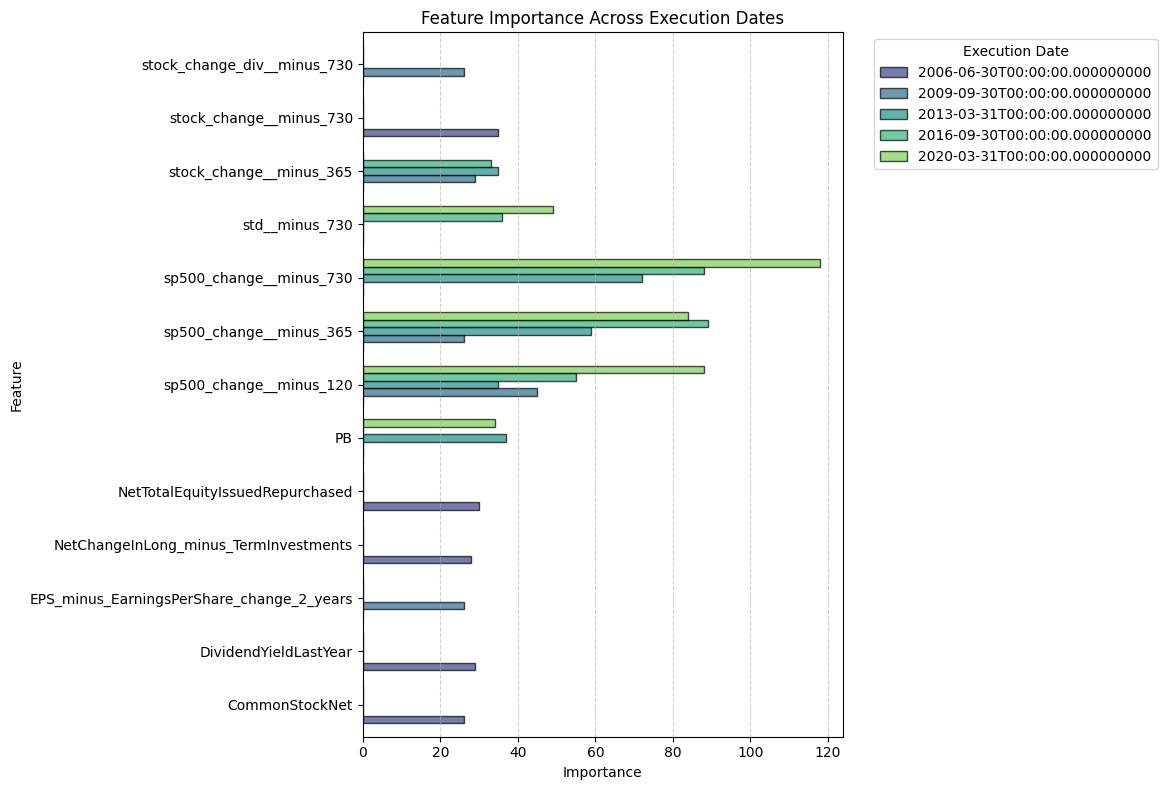

In [138]:
num_models = 5
sorted_dates = sorted(all_models.keys())
selected_indexes = np.linspace(0, len(sorted_dates) - 1, num_models, dtype=int)
selected_dates = [sorted_dates[i] for i in selected_indexes]
selected_models = [all_models[date] for date in selected_dates]

all_feature_importance = []

for date, model in zip(selected_dates, selected_models):
    fi = model.feature_importance()
    fn = model.feature_name()
    
    feature_importance = pd.DataFrame({
        "feature": fn,
        "importance": fi,
        "execution_date": str(date) 
    })

    feature_importance = feature_importance.sort_values("importance", ascending=False).head(5)
    
    all_feature_importance.append(feature_importance)

df_feature_importance = pd.concat(all_feature_importance)

pivot_df = df_feature_importance.pivot(index="feature", columns="execution_date", values="importance")

fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(pivot_df.columns)))

pivot_df.plot(kind="barh", ax=ax, alpha=0.7, color=colors, edgecolor="black", width=0.7)

ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.set_title("Feature Importance Across Execution Dates")
ax.legend(title="Execution Date", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

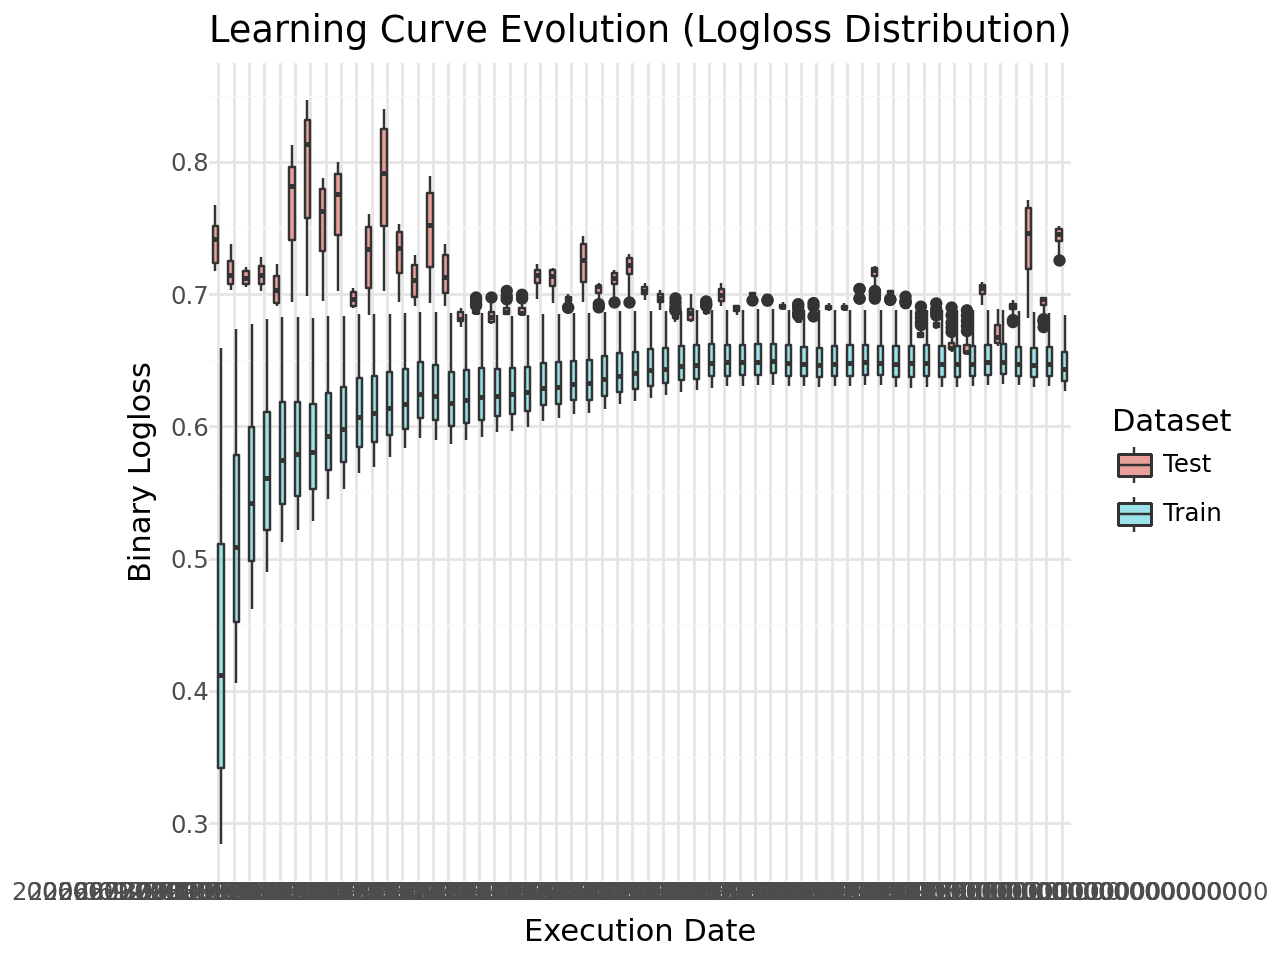

In [139]:
ggplot_phase_curve = plot_phase_curve_boxplot(all_results)
ggplot_phase_curve

In [140]:
train_outperformance = train_results_final_tree[train_results_final_tree['weighted-return'] > 0].shape[0] / train_results_final_tree.shape[0]
test_outperformance = test_results_final_tree[test_results_final_tree['weighted-return'] > 0].shape[0] / test_results_final_tree.shape[0]
print(f'Percentage of execution dates in which the chosen portfolio outperforms SP500 in train dataset: {round(train_outperformance*100, 2)}')
print(f'Percentage of execution dates in which the chosen portfolio outperforms SP500 in test dataset: {round(test_outperformance*100, 2)}')
print('\n')
mean_train_performance_difference = train_results_final_tree['weighted-return'].mean()
mean_test_performance_difference = test_results_final_tree['weighted-return'].mean()
print(f'Mean difference in performance (between our portfolio and SP500) for train dataset: {round(mean_train_performance_difference, 4)}')
print(f'Mean difference in performance (between our portfolio and SP500) for test dataset: {round(mean_test_performance_difference, 4)}')
print('\n')
median_train_performance_difference = train_results_final_tree['weighted-return'].median()
median_test_performance_difference = test_results_final_tree['weighted-return'].median()
print(f'Median difference in performance (between our portfolio and SP500) for train dataset: {round(median_train_performance_difference, 4)}')
print(f'Median difference in performance (between our portfolio and SP500) for test dataset: {round(median_test_performance_difference, 4)}')

Percentage of execution dates in which the chosen portfolio outperforms SP500 in train dataset: 100.0
Percentage of execution dates in which the chosen portfolio outperforms SP500 in test dataset: 60.71


Mean difference in performance (between our portfolio and SP500) for train dataset: 2.312
Mean difference in performance (between our portfolio and SP500) for test dataset: 0.0051


Median difference in performance (between our portfolio and SP500) for train dataset: 2.3643
Median difference in performance (between our portfolio and SP500) for test dataset: 0.0196
